# CNN Transfer Learning para Flotation Froth Sequence Images

- Dorian Ticona

In [ ]:
!pip -q install seaborn tqdm scikit-learn

In [ ]:
import os
import re
import copy
import time
import zipfile
from pathlib import Path
from collections import Counter

try:
    import sympy as _sympy
    import sympy.printing as _sympy_printing
    if not hasattr(_sympy, 'printing'):
        _sympy.printing = _sympy_printing
    print('SymPy compatibility OK:', getattr(_sympy, '__version__', 'unknown'))
except Exception as e:
    raise RuntimeError(
        'SymPy compatibility check failed before importing PyTorch. '
        'In Colab, run: !pip -q install --upgrade sympy and restart runtime.'
    ) from e

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

SymPy compatibility OK: 1.14.0
DEVICE: cuda
GPU: Tesla T4


## 1. Configuración del experimento

In [ ]:
# Modelo recomendado para empezar: resnet18.
# Alternatives: 'mobilenet_v3_small', 'efficientnet_b0'.
MODEL_NAME = 'resnet18'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

FAST_DEV_RUN = False
FAST_DEV_SAMPLES_PER_CLASS = 80

# Baseline Pipeline A para comparación.
PIPELINE_A_HOLDOUT_MACRO_F1 = 0.8771
PIPELINE_A_CV_MACRO_F1 = 0.8466

## 2. Montar Drive y resolver ruta del dataset

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print('No parece ser Colab o Drive ya está montado:', e)

Mounted at /content/drive


In [ ]:
DRIVE_ROOT = Path('/content/drive/MyDrive') if Path('/content/drive/MyDrive').exists() else Path.cwd()

DATASET_ROOT = DRIVE_ROOT / 'Amta_lab' / 'datasets' / 'Dataset: "Flotation Froth Sequence Images"'

print('DATASET_ROOT =', DATASET_ROOT)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        'No existe la ruta exacta indicada. Verificá en Drive que sea exactamente: '
        'Amta_lab/datasets/Dataset: "Flotation Froth Sequence Images"'
    )

print('Contenido inicial:')
for x in sorted(DATASET_ROOT.iterdir())[:20]:
    print(' -', x.name)

DATASET_ROOT = /content/drive/MyDrive/Amta_lab/datasets/Dataset: "Flotation Froth Sequence Images"
Contenido inicial:
 - class Ⅰ.zip
 - class Ⅱ.zip
 - class Ⅲ.zip
 - class Ⅳ.zip


## 3. Preparar dataset: ZIPs o carpetas extraídas

In [ ]:
WORK_DIR = Path('/content/drn_pipeline_b_work') if IN_COLAB else Path.cwd() / 'drn_pipeline_b_work'
EXTRACT_DIR = WORK_DIR / 'extracted'
OUTPUT_DIR = WORK_DIR / 'outputs'
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

zip_files = sorted(DATASET_ROOT.glob('*.zip'))

if zip_files:
    print(f'Se encontraron {len(zip_files)} ZIPs. Extrayendo/reutilizando en: {EXTRACT_DIR}')
    for z in zip_files:
        target = EXTRACT_DIR / z.stem
        if target.exists() and any(target.iterdir()):
            print('Ya extraído:', z.name)
            continue
        target.mkdir(parents=True, exist_ok=True)
        print('Extrayendo:', z.name)
        with zipfile.ZipFile(z, 'r') as zip_ref:
            zip_ref.extractall(target)
    DATA_ROOT = EXTRACT_DIR
else:
    print('No se encontraron ZIPs. Asumo dataset ya extraído.')
    DATA_ROOT = DATASET_ROOT

print('DATA_ROOT =', DATA_ROOT)
for x in sorted(DATA_ROOT.iterdir())[:20]:
    print(' -', x.name)

Se encontraron 4 ZIPs. Extrayendo/reutilizando en: /content/drn_pipeline_b_work/extracted
Extrayendo: class Ⅰ.zip
Extrayendo: class Ⅱ.zip
Extrayendo: class Ⅲ.zip
Extrayendo: class Ⅳ.zip
DATA_ROOT = /content/drn_pipeline_b_work/extracted
 - class Ⅰ
 - class Ⅱ
 - class Ⅲ
 - class Ⅳ


## 4. Indexar secuencias

Cada muestra será una secuencia. Para este primer CNN baseline usamos el **frame central** de la secuencia.

In [ ]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def normalize_label(name: str) -> str:
    s = name.strip()
    s = s.replace('Ⅰ', 'I').replace('Ⅱ', 'II').replace('Ⅲ', 'III').replace('Ⅳ', 'IV')
    s = re.sub(r'[_\-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

def image_files_in_dir(d: Path):
    return sorted([p for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

def find_sequence_dirs(class_dir: Path):
    seq_dirs = []
    for d in class_dir.rglob('*'):
        if d.is_dir() and len(image_files_in_dir(d)) >= 2:
            seq_dirs.append(d)
    if not seq_dirs and len(image_files_in_dir(class_dir)) >= 2:
        seq_dirs = [class_dir]
    return sorted(set(seq_dirs))

first_level_dirs = [p for p in DATA_ROOT.iterdir() if p.is_dir()]
class_dirs = [p for p in first_level_dirs if re.search(r'class|Ⅰ|Ⅱ|Ⅲ|Ⅳ|\bI{1,3}V?\b', p.name, re.IGNORECASE)]

if len(class_dirs) == 0 and len(first_level_dirs) == 1:
    nested = first_level_dirs[0]
    maybe = [p for p in nested.iterdir() if p.is_dir() and re.search(r'class|Ⅰ|Ⅱ|Ⅲ|Ⅳ|\bI{1,3}V?\b', p.name, re.IGNORECASE)]
    if maybe:
        DATA_ROOT = nested
        class_dirs = maybe

if not class_dirs:
    class_dirs = first_level_dirs

rows = []
for class_dir in sorted(class_dirs):
    label = normalize_label(class_dir.name)
    for seq_dir in find_sequence_dirs(class_dir):
        frames = image_files_in_dir(seq_dir)
        if len(frames) < 2:
            continue
        center_frame = frames[len(frames)//2]
        rows.append({
            'sequence_id': f'{label}__{seq_dir.name}',
            'label': label,
            'sequence_dir': str(seq_dir),
            'n_frames': len(frames),
            'image_path': str(center_frame),
            'frame_paths': [str(p) for p in frames],
        })

index_df = pd.DataFrame(rows)
print('Secuencias indexadas:', len(index_df))
display(index_df.head())
print('Distribución por clase:', Counter(index_df['label']))

if FAST_DEV_RUN:
    index_df = pd.concat([
        g.sample(min(len(g), FAST_DEV_SAMPLES_PER_CLASS), random_state=RANDOM_STATE)
        for _, g in index_df.groupby('label')
    ], ignore_index=True)
    print('FAST_DEV_RUN activo:', len(index_df), Counter(index_df['label']))

Secuencias indexadas: 2386


,sequence_id,label,sequence_dir,n_frames,image_path,frame_paths
0,class I__1001,class I,/content/drn_pipeline_b_work/extracted/class Ⅰ...,12,/content/drn_pipeline_b_work/extracted/class Ⅰ...,[/content/drn_pipeline_b_work/extracted/class ...
1,class I__1002,class I,/content/drn_pipeline_b_work/extracted/class Ⅰ...,12,/content/drn_pipeline_b_work/extracted/class Ⅰ...,[/content/drn_pipeline_b_work/extracted/class ...
2,class I__1003,class I,/content/drn_pipeline_b_work/extracted/class Ⅰ...,12,/content/drn_pipeline_b_work/extracted/class Ⅰ...,[/content/drn_pipeline_b_work/extracted/class ...
3,class I__1004,class I,/content/drn_pipeline_b_work/extracted/class Ⅰ...,12,/content/drn_pipeline_b_work/extracted/class Ⅰ...,[/content/drn_pipeline_b_work/extracted/class ...
4,class I__1005,class I,/content/drn_pipeline_b_work/extracted/class Ⅰ...,12,/content/drn_pipeline_b_work/extracted/class Ⅰ...,[/content/drn_pipeline_b_work/extracted/class ...


Distribución por clase: Counter({'class II': 696, 'class I': 660, 'class III': 625, 'class IV': 405})


## 5. Encode labels y split por secuencia

In [ ]:
label_encoder = LabelEncoder()
index_df['label_id'] = label_encoder.fit_transform(index_df['label'])
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print('Clases:', dict(enumerate(class_names)))

train_df, temp_df = train_test_split(index_df, test_size=0.30, random_state=RANDOM_STATE, stratify=index_df['label_id'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_STATE, stratify=temp_df['label_id'])

print('Train:', len(train_df), Counter(train_df['label']))
print('Val:', len(val_df), Counter(val_df['label']))
print('Test:', len(test_df), Counter(test_df['label']))

Clases: {0: 'class I', 1: 'class II', 2: 'class III', 3: 'class IV'}
Train: 1670 Counter({'class II': 487, 'class I': 462, 'class III': 437, 'class IV': 284})
Val: 358 Counter({'class II': 104, 'class I': 99, 'class III': 94, 'class IV': 61})
Test: 358 Counter({'class II': 105, 'class I': 99, 'class III': 94, 'class IV': 60})


## 6. Dataset y transforms

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class FrothCenterFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_bgr = cv2.imread(row['image_path'], cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f'No se pudo leer imagen: {row["image_path"]}')
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        if self.transform:
            img_rgb = self.transform(img_rgb)
        y = int(row['label_id'])
        return img_rgb, y

train_ds = FrothCenterFrameDataset(train_df, train_tfms)
val_ds = FrothCenterFrameDataset(val_df, valid_tfms)
test_ds = FrothCenterFrameDataset(test_df, valid_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Batches train/val/test:', len(train_loader), len(val_loader), len(test_loader))

Batches train/val/test: 53 12 12


## 7. Visualizar batch de entrenamiento

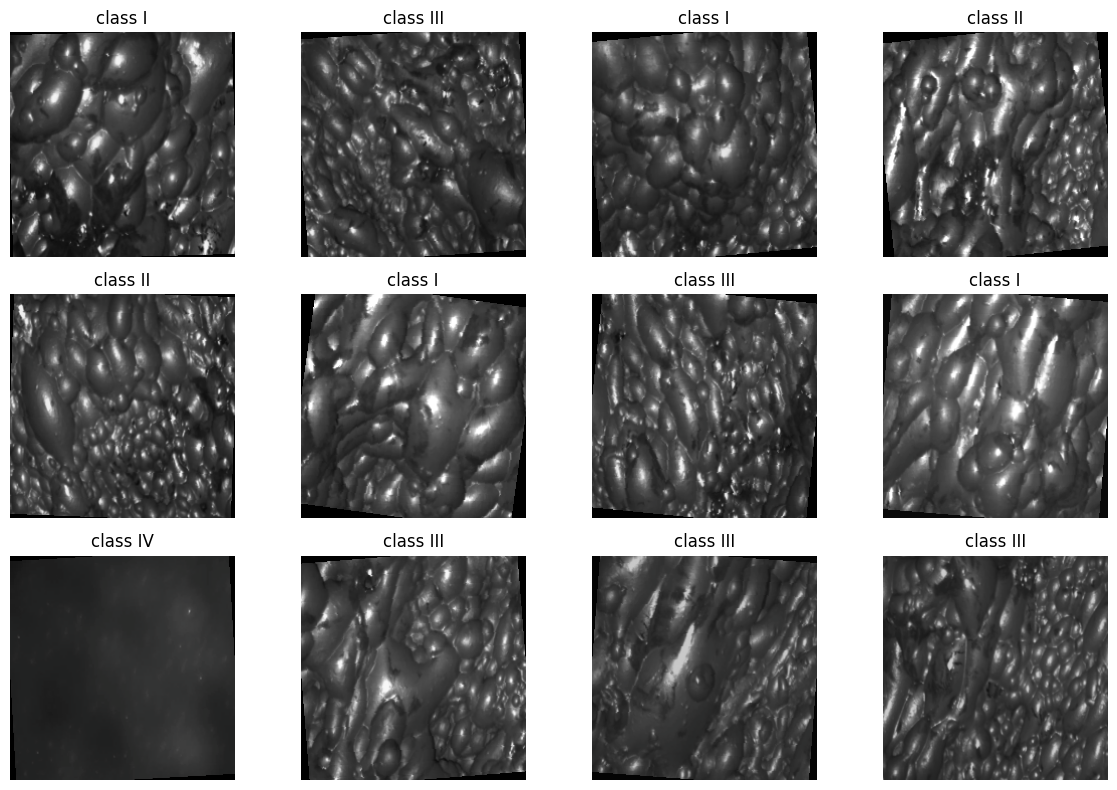

In [ ]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(t.cpu() * std + mean, 0, 1)

xb, yb = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(min(12, xb.size(0))):
    plt.subplot(3, 4, i+1)
    plt.imshow(denormalize(xb[i]).permute(1,2,0))
    plt.title(class_names[yb[i].item()])
    plt.axis('off')
plt.tight_layout()

## 8. Crear modelo preentrenado

In [ ]:
def create_model(model_name, num_classes):
    model_name = model_name.lower()
    if model_name == 'resnet18':
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'mobilenet_v3_small':
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        raise ValueError(f'MODEL_NAME no soportado: {model_name}')
    return model

model = create_model(MODEL_NAME, num_classes).to(DEVICE)
print(model.__class__.__name__)
print('Parámetros entrenables:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


ResNet
Parámetros entrenables: 11178564


## 9. Loss con class weights y optimizador

In [ ]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=train_df['label_id'].values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print('class_weights:', class_weights.detach().cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

class_weights: [0.90367967 0.85728955 0.9553776  1.4700705 ]


## 10. Funciones de entrenamiento/evaluación

In [ ]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_y = []
    all_pred = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        all_y.extend(yb.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_pred)
    macro_f1 = f1_score(all_y, all_pred, average='macro')
    return avg_loss, acc, macro_f1, np.array(all_y), np.array(all_pred)

history = []
best_state = None
best_val_f1 = -1

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, optimizer=None)
    scheduler.step(val_f1)
    row = {'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'train_macro_f1': train_f1, 'val_loss': val_loss, 'val_acc': val_acc, 'val_macro_f1': val_f1, 'lr': optimizer.param_groups[0]['lr']}
    history.append(row)
    print(row)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

elapsed = time.time() - start
print(f'Tiempo total: {elapsed/60:.2f} min')
history_df = pd.DataFrame(history)
display(history_df)

{'epoch': 1, 'train_loss': 0.6203408768077097, 'train_acc': 0.681437125748503, 'train_macro_f1': 0.7083604969246384, 'val_loss': 0.5098956654358177, 'val_acc': 0.7178770949720671, 'val_macro_f1': 0.6838089542036911, 'lr': 0.0001}
{'epoch': 2, 'train_loss': 0.45711041906636635, 'train_acc': 0.7712574850299401, 'train_macro_f1': 0.7912255417445848, 'val_loss': 0.44515149220408007, 'val_acc': 0.7793296089385475, 'val_macro_f1': 0.8045503347227485, 'lr': 0.0001}
{'epoch': 3, 'train_loss': 0.38515591089597007, 'train_acc': 0.8077844311377246, 'train_macro_f1': 0.8257179690235308, 'val_loss': 0.45373573449736865, 'val_acc': 0.7625698324022346, 'val_macro_f1': 0.7834821428571428, 'lr': 0.0001}
{'epoch': 4, 'train_loss': 0.344976584925623, 'train_acc': 0.8359281437125748, 'train_macro_f1': 0.8511715816396626, 'val_loss': 0.4612164633900094, 'val_acc': 0.7625698324022346, 'val_macro_f1': 0.7699520312216577, 'lr': 0.0001}
{'epoch': 5, 'train_loss': 0.288754142829758, 'train_acc': 0.8604790419161

,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1,lr
0,1,0.620341,0.681437,0.708360,0.509896,0.717877,0.683809,0.00010
1,2,0.457110,0.771257,0.791226,0.445151,0.779330,0.804550,0.00010
2,3,0.385156,0.807784,0.825718,0.453736,0.762570,0.783482,0.00010
3,4,0.344977,0.835928,0.851172,0.461216,0.762570,0.769952,0.00010
4,5,0.288754,0.860479,0.873378,0.608345,0.723464,0.732479,0.00005
5,6,0.212537,0.910778,0.919129,0.474590,0.787709,0.808785,0.00005
6,7,0.166610,0.935329,0.941617,0.452543,0.773743,0.792793,0.00005
7,8,0.154390,0.943114,0.948759,0.555900,0.751397,0.763829,0.00005


## 11. Curvas de entrenamiento

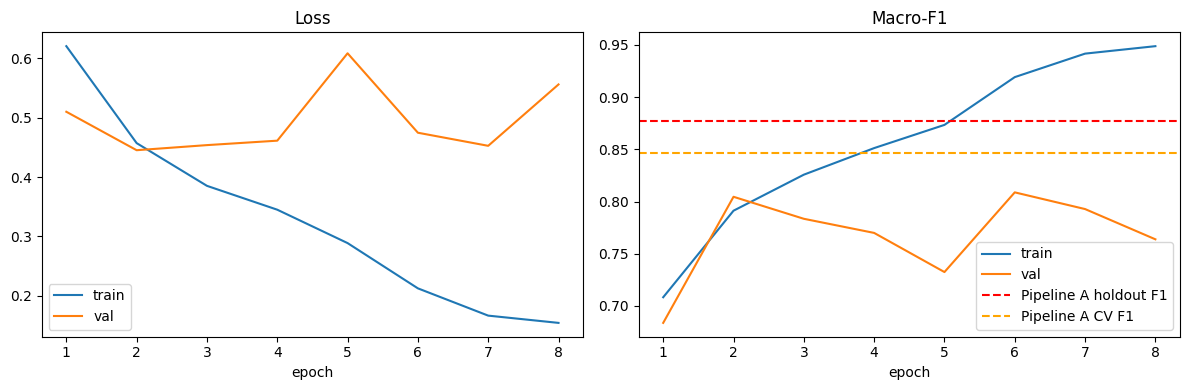

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_macro_f1'], label='train')
plt.plot(history_df['epoch'], history_df['val_macro_f1'], label='val')
plt.axhline(PIPELINE_A_HOLDOUT_MACRO_F1, color='red', linestyle='--', label='Pipeline A holdout F1')
plt.axhline(PIPELINE_A_CV_MACRO_F1, color='orange', linestyle='--', label='Pipeline A CV F1')
plt.title('Macro-F1')
plt.xlabel('epoch')
plt.legend()
plt.tight_layout()

## 12. Evaluación en test con mejor checkpoint

In [ ]:
model.load_state_dict(best_state)
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(model, test_loader, optimizer=None)

print('Test loss:', test_loss)
print('Test accuracy:', test_acc)
print('Test macro-F1:', test_f1)
print('Comparación contra Pipeline A:')
print('Pipeline A holdout macro-F1:', PIPELINE_A_HOLDOUT_MACRO_F1)
print('Pipeline A CV macro-F1:', PIPELINE_A_CV_MACRO_F1)
print('Delta vs A holdout:', test_f1 - PIPELINE_A_HOLDOUT_MACRO_F1)
print('Delta vs A CV:', test_f1 - PIPELINE_A_CV_MACRO_F1)
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Test loss: 0.4620937678401031
Test accuracy: 0.7849162011173184
Test macro-F1: 0.8026710462658824
Comparación contra Pipeline A:
Pipeline A holdout macro-F1: 0.8771
Pipeline A CV macro-F1: 0.8466
Delta vs A holdout: -0.07442895373411762
Delta vs A CV: -0.04392895373411765
Classification report:
              precision    recall  f1-score   support

     class I       0.91      0.84      0.87        99
    class II       0.63      0.85      0.72       105
   class III       0.75      0.52      0.62        94
    class IV       1.00      1.00      1.00        60

    accuracy                           0.78       358
   macro avg       0.82      0.80      0.80       358
weighted avg       0.80      0.78      0.78       358



## 13. Matriz de confusión

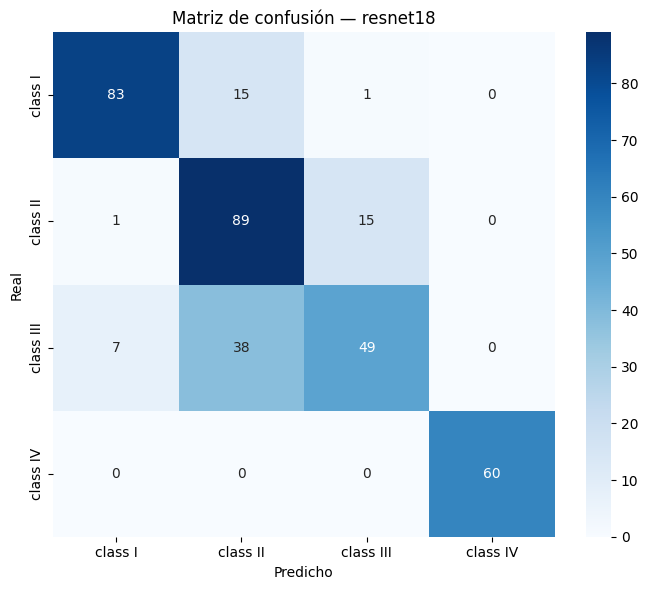

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de confusión — {MODEL_NAME}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()

## 14. Inspección de errores

In [ ]:
test_eval_df = test_df.copy().reset_index(drop=True)
test_eval_df['pred_id'] = y_pred
test_eval_df['pred_label'] = [class_names[i] for i in y_pred]
test_eval_df['correct'] = test_eval_df['label_id'] == test_eval_df['pred_id']
errors_df = test_eval_df[~test_eval_df['correct']]
print('Errores:', len(errors_df), '/', len(test_eval_df))
display(errors_df[['sequence_id', 'label', 'pred_label', 'image_path']].head(20))

Errores: 77 / 358


,sequence_id,label,pred_label,image_path
3,class III__1318,class III,class II,/content/drn_pipeline_b_work/extracted/class Ⅲ...
5,class III__1443,class III,class II,/content/drn_pipeline_b_work/extracted/class Ⅲ...
10,class I__1340,class I,class II,/content/drn_pipeline_b_work/extracted/class Ⅰ...
18,class II__1638,class II,class III,/content/drn_pipeline_b_work/extracted/class Ⅱ...
19,class III__1564,class III,class I,/content/drn_pipeline_b_work/extracted/class Ⅲ...
21,class II__1106,class II,class III,/content/drn_pipeline_b_work/extracted/class Ⅱ...
24,class III__1618,class III,class II,/content/drn_pipeline_b_work/extracted/class Ⅲ...
26,class III__1301,class III,class II,/content/drn_pipeline_b_work/extracted/class Ⅲ...
36,class III__1527,class III,class I,/content/drn_pipeline_b_work/extracted/class Ⅲ...
40,class II__1485,class II,class III,/content/drn_pipeline_b_work/extracted/class Ⅱ...


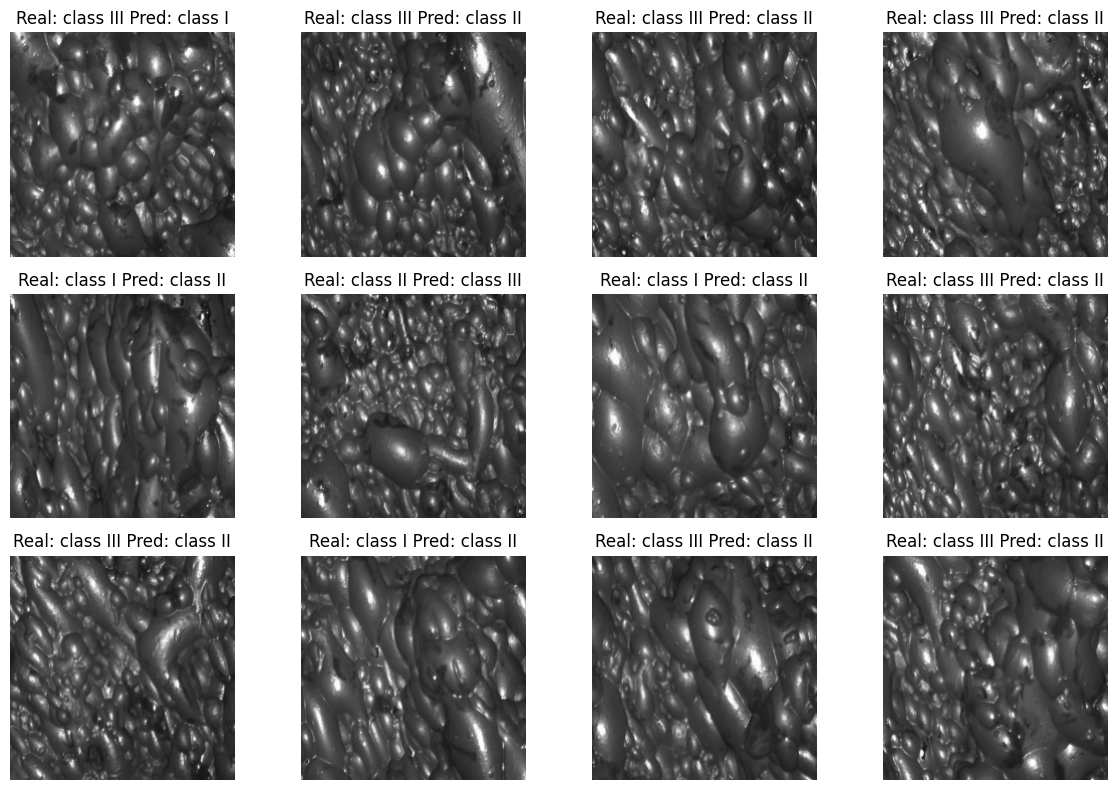

In [ ]:
def read_image_rgb(path, resize_to=(224,224)):
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return cv2.resize(img_rgb, resize_to, interpolation=cv2.INTER_AREA)

sample_errors = errors_df.sample(min(12, len(errors_df)), random_state=RANDOM_STATE) if len(errors_df) else errors_df
plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(sample_errors.iterrows()):
    plt.subplot(3, 4, i+1)
    plt.imshow(read_image_rgb(row['image_path']))
    plt.title(f"Real: {row['label']} Pred: {row['pred_label']}")
    plt.axis('off')
plt.tight_layout()